In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DRIVE_ROOT = Path("/content/drive/MyDrive/semantic-drift")
PROC_ROOT = DRIVE_ROOT / "reddit_data" / "processed"
MONTHLY_ROOT = PROC_ROOT / "monthly"
RESULTS_ROOT = PROC_ROOT / "results"

TARGET_SUBREDDITS = [
    "Decadeology",
    "GenAlpha",
    "GenZ",
    "Youtube",
]

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

In [3]:
CONTEXT_ROOT = PROC_ROOT / "contexts"
EMBED_ROOT = PROC_ROOT / "embeddings"

CONTEXT_ROOT.mkdir(parents=True, exist_ok=True)
EMBED_ROOT.mkdir(parents=True, exist_ok=True)

In [ ]:
def stream_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except Exception:
                continue

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
for sub in TARGET_SUBREDDITS:
    sub_dir = MONTHLY_ROOT / sub
    print("\nSUBREDDIT:", sub)
    print("Exists:", sub_dir.exists())
    if sub_dir.exists():
        files = sorted(sub_dir.glob("*.jsonl"))
        print("Num files:", len(files))
        print("First 3 files:", [f.name for f in files[:3]])


SUBREDDIT: Decadeology
Exists: True
Num files: 70
First 3 files: ['2015-12.jsonl', '2016-01.jsonl', '2016-02.jsonl']

SUBREDDIT: GenAlpha
Exists: True
Num files: 89
First 3 files: ['2018-10.jsonl', '2018-11.jsonl', '2018-12.jsonl']

SUBREDDIT: GenZ
Exists: True
Num files: 104
First 3 files: ['2016-01.jsonl', '2016-02.jsonl', '2016-11.jsonl']

SUBREDDIT: Youtube
Exists: True
Num files: 201
First 3 files: ['2008-03.jsonl', '2008-04.jsonl', '2008-05.jsonl']


In [ ]:
def count_word_across_subreddits(word):
    word = word.lower().strip()
    pattern = re.compile(rf"\b{re.escape(word)}\b", re.IGNORECASE)

    rows = []

    for subreddit in TARGET_SUBREDDITS:
        sub_dir = MONTHLY_ROOT / subreddit
        if not sub_dir.exists():
            continue

        for file_path in sorted(sub_dir.glob("*.jsonl")):
            month = file_path.stem
            token_count = 0
            comment_count = 0

            for obj in stream_jsonl(file_path):
                text = clean_text(obj.get("text", ""))
                matches = pattern.findall(text)
                if matches:
                    token_count += len(matches)
                    comment_count += 1

            rows.append({
                "word": word,
                "subreddit": subreddit,
                "month": month,
                "token_count": token_count,
                "comment_count": comment_count
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["month", "subreddit"]).reset_index(drop=True)
    return df

In [ ]:
def quick_word_count(words):
    rows = []
    for word in words:
        df = count_word_across_subreddits(word)
        total = int(df["token_count"].sum()) if not df.empty else 0
        rows.append({"word": word, "total_mentions": total})
    return pd.DataFrame(rows).sort_values("total_mentions", ascending=False).reset_index(drop=True)

In [ ]:
CANDIDATE_WORDS = [
    "rizz", "skibidi", "sigma", "aura", "based",
    "npc", "cringe", "cap", "core", "vibe"
]

quick_word_count(CANDIDATE_WORDS)

,word,total_mentions
0,based,133711
1,cringe,35026
2,core,30313
3,skibidi,25448
4,vibe,15684
5,sigma,8403
6,cap,7755
7,rizz,6445
8,npc,2155
9,aura,2092


In [ ]:
def extract_contexts_across_subreddits(word, max_contexts_per_subreddit=1500):
    word = word.lower().strip()
    pattern = re.compile(rf"\b{re.escape(word)}\b", re.IGNORECASE)

    rows = []

    for subreddit in TARGET_SUBREDDITS:
        sub_dir = MONTHLY_ROOT / subreddit
        if not sub_dir.exists():
            continue

        sub_count = 0

        for file_path in sorted(sub_dir.glob("*.jsonl")):
            month = file_path.stem

            for obj in stream_jsonl(file_path):
                text = clean_text(obj.get("text", ""))
                if not text:
                    continue

                if pattern.search(text):
                    rows.append({
                        "word": word,
                        "subreddit": subreddit,
                        "month": month,
                        "text": text
                    })
                    sub_count += 1

                    if sub_count >= max_contexts_per_subreddit:
                        break

            if sub_count >= max_contexts_per_subreddit:
                break

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["month", "subreddit"]).reset_index(drop=True)
    return df

In [ ]:
df_rizz = extract_contexts_across_subreddits("rizz", max_contexts_per_subreddit=1000)
df_rizz.head()

,word,subreddit,month,text
0,rizz,GenZ,2022-09,you got some unspoken rizz? you could put that...
1,rizz,GenZ,2022-10,op ain’t got no rizz
2,rizz,GenZ,2022-10,"""rizz"" i hate that stupid word and how it sounds"
3,rizz,GenZ,2022-12,"this is so true, they say ""gaslighting"" becaus..."
4,rizz,GenZ,2023-01,"aye i see you, if you willin to rizz her up th..."


In [ ]:
def split_early_late(context_df):
    if context_df.empty:
        return context_df.copy(), context_df.copy()

    months = sorted(context_df["month"].unique())
    midpoint = len(months) // 2

    early_months = set(months[:midpoint])
    late_months = set(months[midpoint:])

    early_df = context_df[context_df["month"].isin(early_months)].copy()
    late_df = context_df[context_df["month"].isin(late_months)].copy()

    return early_df, late_df

In [ ]:
early_df, late_df = split_early_late(df_rizz)

print("Early:", early_df.shape)
print("Late:", late_df.shape)

Early: (2047, 4)
Late: (342, 4)


In [ ]:
def plot_reddit_usage(word_df, word):
    if word_df.empty:
        print("No data found.")
        return

    monthly = (
        word_df.groupby("month", as_index=False)["token_count"]
        .sum()
        .sort_values("month")
    )

    plt.figure(figsize=(14, 5))
    plt.plot(monthly["month"], monthly["token_count"])
    ticks = monthly["month"].tolist()[::12] if len(monthly) > 12 else monthly["month"].tolist()
    plt.xticks(ticks, rotation=45)
    plt.title(f"Monthly Reddit usage of '{word}'")
    plt.xlabel("Month")
    plt.ylabel("Token count")
    plt.tight_layout()
    plt.show()
    plt.close()

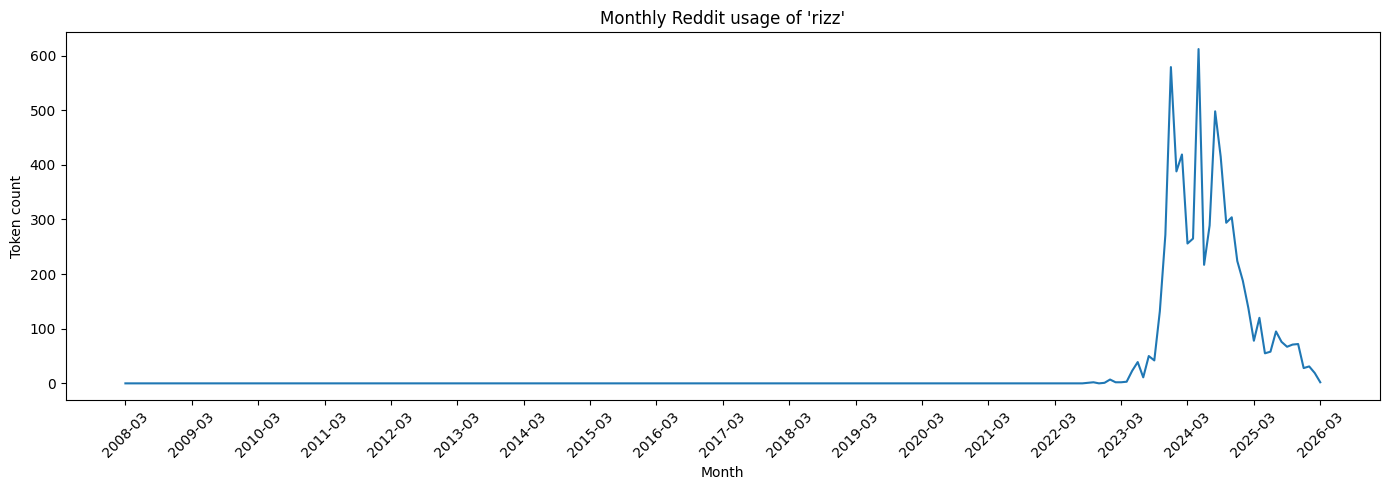

In [ ]:
word_counts = count_word_across_subreddits("rizz")
plot_reddit_usage(word_counts, "rizz")

In [ ]:
!pip -q install sentence-transformers umap-learn

In [ ]:
from sentence_transformers import SentenceTransformer
import umap.umap_ as umap

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def encode_texts(texts, model):
    if not texts:
        return None
    return model.encode(texts, batch_size=64, show_progress_bar=True)

In [ ]:
early_emb = encode_texts(early_df["text"].tolist(), embed_model)
late_emb = encode_texts(late_df["text"].tolist(), embed_model)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
def plot_old_vs_new_embeddings(word, early_emb, late_emb):
    if early_emb is None or late_emb is None:
        print("No embeddings available.")
        return

    all_emb = np.vstack([early_emb, late_emb])
    labels = np.array(["Old"] * len(early_emb) + ["New"] * len(late_emb))

    reducer = umap.UMAP(n_components=2, random_state=42)
    coords = reducer.fit_transform(all_emb)

    old_mask = labels == "Old"
    new_mask = labels == "New"

    plt.figure(figsize=(10, 6))
    plt.scatter(coords[old_mask, 0], coords[old_mask, 1], s=30, alpha=0.7, label="Old")
    plt.scatter(coords[new_mask, 0], coords[new_mask, 1], s=30, alpha=0.7, label="New")
    plt.title(f"Old vs New contexts for '{word}'")
    plt.xlabel("Semantic Dimension 1")
    plt.ylabel("Semantic Dimension 2")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


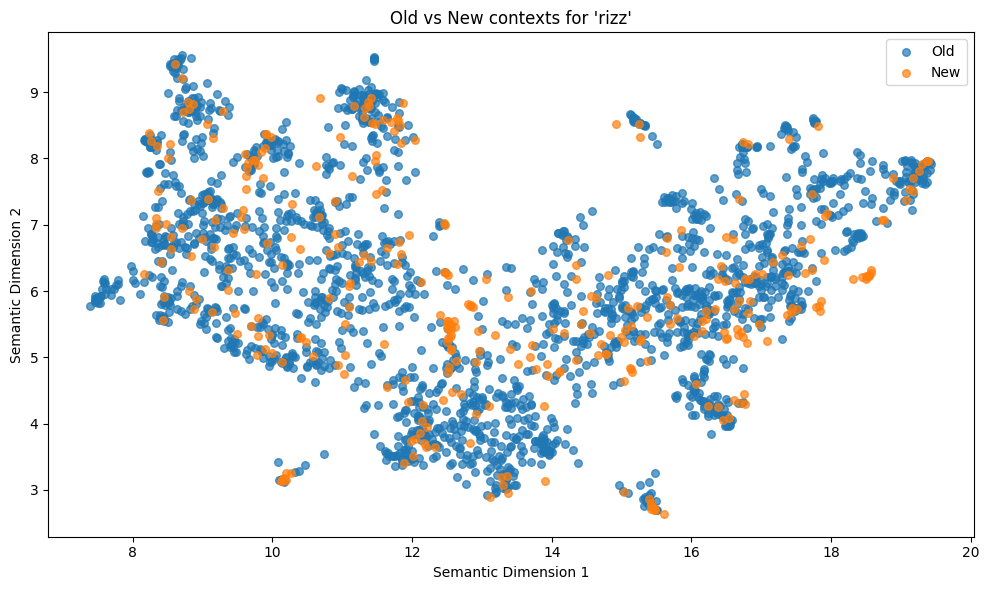

In [ ]:
plot_old_vs_new_embeddings("rizz", early_emb, late_emb)

In [ ]:
def save_reddit_outputs(word, contexts_df, early_df, late_df):
    contexts_df.to_csv(RESULTS_ROOT / f"{word}_contexts.csv", index=False)
    early_df.to_csv(RESULTS_ROOT / f"{word}_early_contexts.csv", index=False)
    late_df.to_csv(RESULTS_ROOT / f"{word}_late_contexts.csv", index=False)
    print("Saved outputs for", word)

In [ ]:
import numpy as np

all_emb = np.vstack([early_emb, late_emb])

In [ ]:
import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(all_emb)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
labels = clusterer.fit_predict(all_emb)

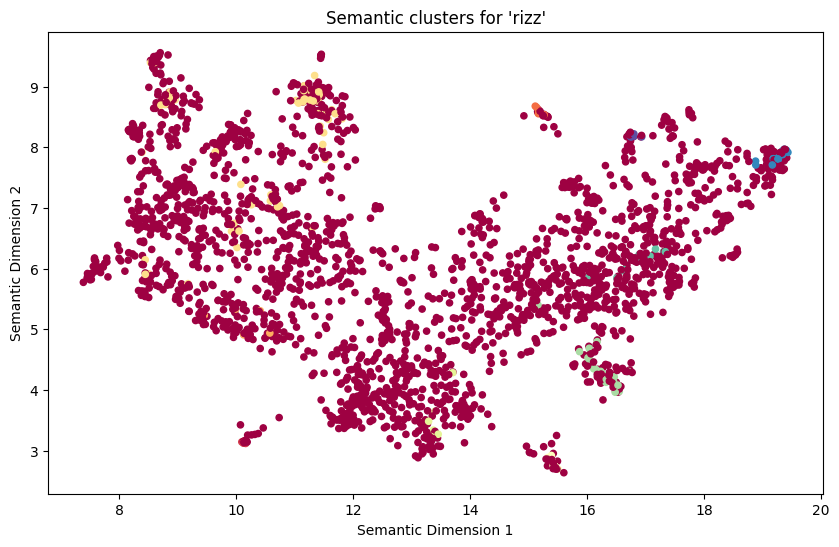

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    coords[:,0],
    coords[:,1],
    c=labels,
    cmap="Spectral",
    s=20
)

plt.title("Semantic clusters for 'rizz'")
plt.xlabel("Semantic Dimension 1")
plt.ylabel("Semantic Dimension 2")

plt.show()

In [ ]:
context_df = pd.concat([early_df, late_df], ignore_index=True)

In [ ]:
context_df["cluster"] = labels

In [ ]:
for c in sorted(context_df["cluster"].unique()):

    print("\n======================")
    print("Cluster:", c)

    examples = context_df[context_df["cluster"] == c]["text"].head(5)

    for e in examples:
        print("-", e)


Cluster: -1
- you got some unspoken rizz? you could put that to use lol
- op ain’t got no rizz
- "rizz" i hate that stupid word and how it sounds
- this is so true, they say "gaslighting" because they're young and go with the flow with whatever anyone says. one famous person calls flirting "rizz" and they fit in like cogs in a machine. i don't like stereotyping this generation but if you're gonna be chatting rubbish to me, it gotta be sad
- aye i see you, if you willin to rizz her up then rizz her up💯

Cluster: 0
- tiktok rizz party
- it's tiktok rizz party
- skibidi tiktok rizz party
- tiktok rizz party and the people associated with it
- 2024 tiktok rizz party

Cluster: 1
- ted hated language change and slang stuff. one of the reasons he was caught was his constant use of the "true" version of the let them eat cake thing. it's just a silly thing i thought of with the ridiculous """controversy""" surrounding rizz being word of the year.
- oh, i use it too, don't get me wrong. ted hat

In [ ]:
import pandas as pd
import os

save_dir = "/content/drive/MyDrive/semantic_drift"
os.makedirs(save_dir, exist_ok=True)

reddit_df = pd.DataFrame({
    "word": "cloud",
    "source": "reddit",
    "text": reddit_contexts
})

save_path = f"{save_dir}/cloud_reddit_contexts_clean.csv"

reddit_df.to_csv(save_path, index=False)

print("Saved Reddit contexts to:", save_path)